In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from helper_functions.data_helper_functions import load_sector_metadata, extract_ceda_data
from helper_functions.lookup_helper_functions import lookup_value, lookup_sector_values, lookup_country_values, find_missing_values, batch_lookup, analyze_zeros_and_missing, find_zeros_by_country_sector
from helper_functions.missing_values import plot_zeros_per_country, plot_zeros_per_industry, list_missing_industries_by_country, print_missing_industries_report, export_missing_industries_to_csv
from helper_functions.null_masking import  convert_zeros_to_true_nulls, create_engineered_nulls, get_masked_values_df
from helper_functions.correlation_calc import match_countries, print_matching_report, calculate_correlations_optimized, rank_indicators_by_correlation, analyze_industry_specific_correlations, save_missing_countries


In [2]:
data_file_path = "data\Open CEDA by Watershed.xlsx"
metadata_file_path = "data\ceda_metadata.xlsx"

In [3]:
# Extract the CEDA data
ceda_data = extract_ceda_data(data_file_path)

if ceda_data is not None:
    print(f"Successfully extracted CEDA data with shape: {ceda_data.shape}")
    print("\nFirst few rows:")
    print(ceda_data.head())
    
    # Display column names (these might be sector codes)
    print("\nColumn names (potential sector codes):")
    print(ceda_data.columns.tolist()[:20])

Successfully extracted CEDA data with shape: (149, 402)

First few rows:
0 Country Code  Country    1111A0    1111B0    111200    111300    111400  \
0          AFG      NaN  0.832288  1.387533  0.597901  0.547433  0.746834   
1          AGO      NaN  0.507764  0.797831  0.378769  0.372152  0.450301   
2          ALB      NaN  0.647701  1.070358  0.455569  0.413583  0.578187   
3          ARE      NaN  0.888452  1.466049  0.633348  0.581714  0.777668   
4          ARG      NaN  0.810486  1.196029  0.565952  0.656380  0.815693   

0    111900    112120    1121A0  ...    813B00    814000    S00500    S00600  \
0  1.342802  1.587646  2.108243  ...  0.374271  0.283056  0.185664  0.156771   
1  0.782578  0.920494  1.222898  ...  0.322642  0.212441  0.156688  0.128459   
2  1.045690  1.216085  1.633651  ...  0.245527  0.240735  0.135756  0.120999   
3  1.441345  1.667556  2.199879  ...  0.383058  0.285956  0.196644  0.165980   
4  1.266295  1.683885  2.896392  ...  0.176149  0.516262  0.1672

In [4]:
# Test single value lookup
print("Testing single value lookup:")
value = lookup_value(ceda_data, 'Afghanistan', '1111A0')
print(f"Afghanistan, 1111A0: {value}")

# Test sector values across all countries
print("\nTesting sector values lookup:")
sector_values = lookup_sector_values(ceda_data, '1111A0')
if sector_values is not None:
    print(f"1111A0 values for first 5 countries:")
    print(sector_values.head())

# Test country values across all sectors
print("\nTesting country values lookup:")
country_values = lookup_country_values(ceda_data, 'Afghanistan')
if country_values is not None:
    print(f"Afghanistan values for first 10 sectors:")
    print(country_values.head(10))

# Find missing values
print("\nChecking for missing values:")
missing_info = find_missing_values(ceda_data)
print(f"Total missing values: {missing_info['total_missing']}")
print(f"Missing percentage: {missing_info['missing_percentage']:.2f}%")

if missing_info['total_missing'] > 0:
    print(f"\nMissing values per column (top 10):")
    print(missing_info['missing_per_column'].head(10))
    
    print(f"\nCountries with missing values (top 10):")
    print(missing_info['missing_per_country'].head(10))

Testing single value lookup:
Country 'Afghanistan' not found in data
Afghanistan, 1111A0: None

Testing sector values lookup:
1111A0 values for first 5 countries:
Country
NaN    0.832288
NaN    0.507764
NaN    0.647701
NaN    0.888452
NaN    0.810486
Name: 1111A0, dtype: float64

Testing country values lookup:
Country 'Afghanistan' not found in data

Checking for missing values:
Total missing values: 149
Missing percentage: 0.25%

Missing values per column (top 10):
0
Country    149
dtype: int64

Countries with missing values (top 10):
Series([], dtype: int64)


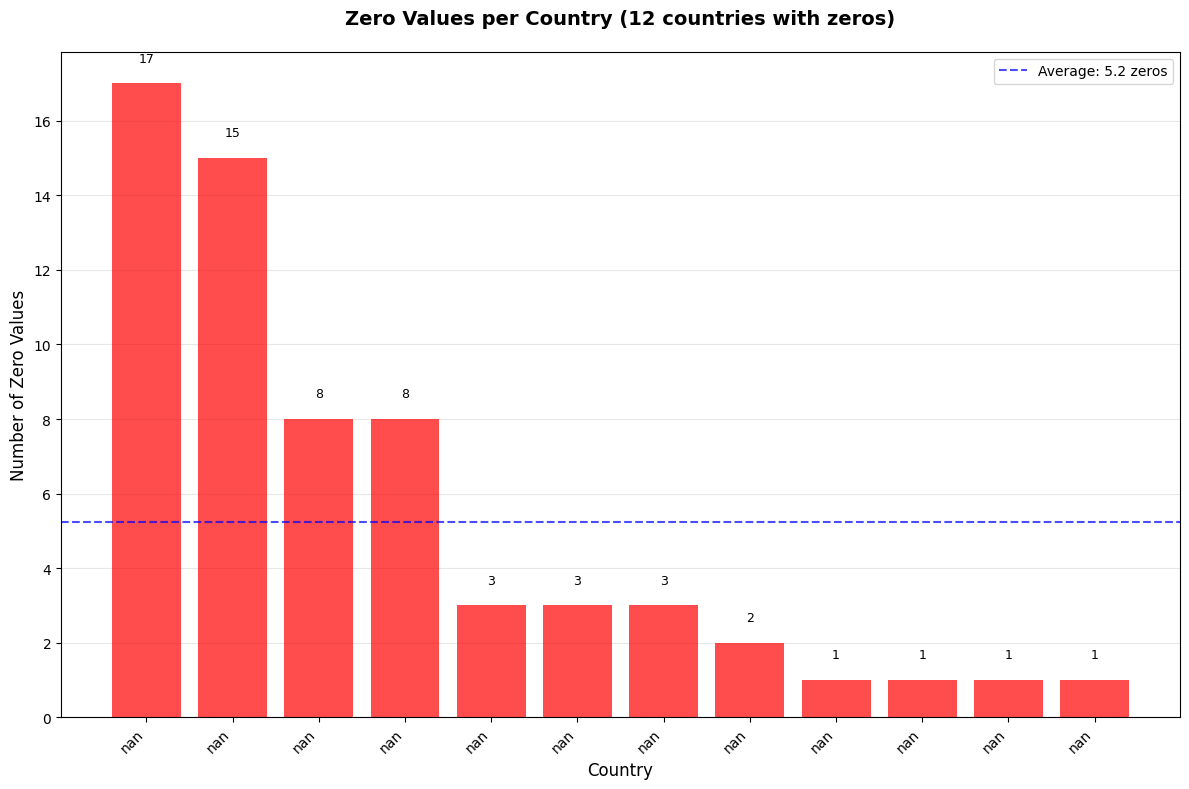


Found 12 countries with zero values
Total zero values across all countries: 63

Top 10 countries with most zeros:
    Country  Zero_Count
4       NaN          17
1       NaN          15
7       NaN           8
10      NaN           8
8       NaN           3
5       NaN           3
0       NaN           3
11      NaN           2
3       NaN           1
2       NaN           1


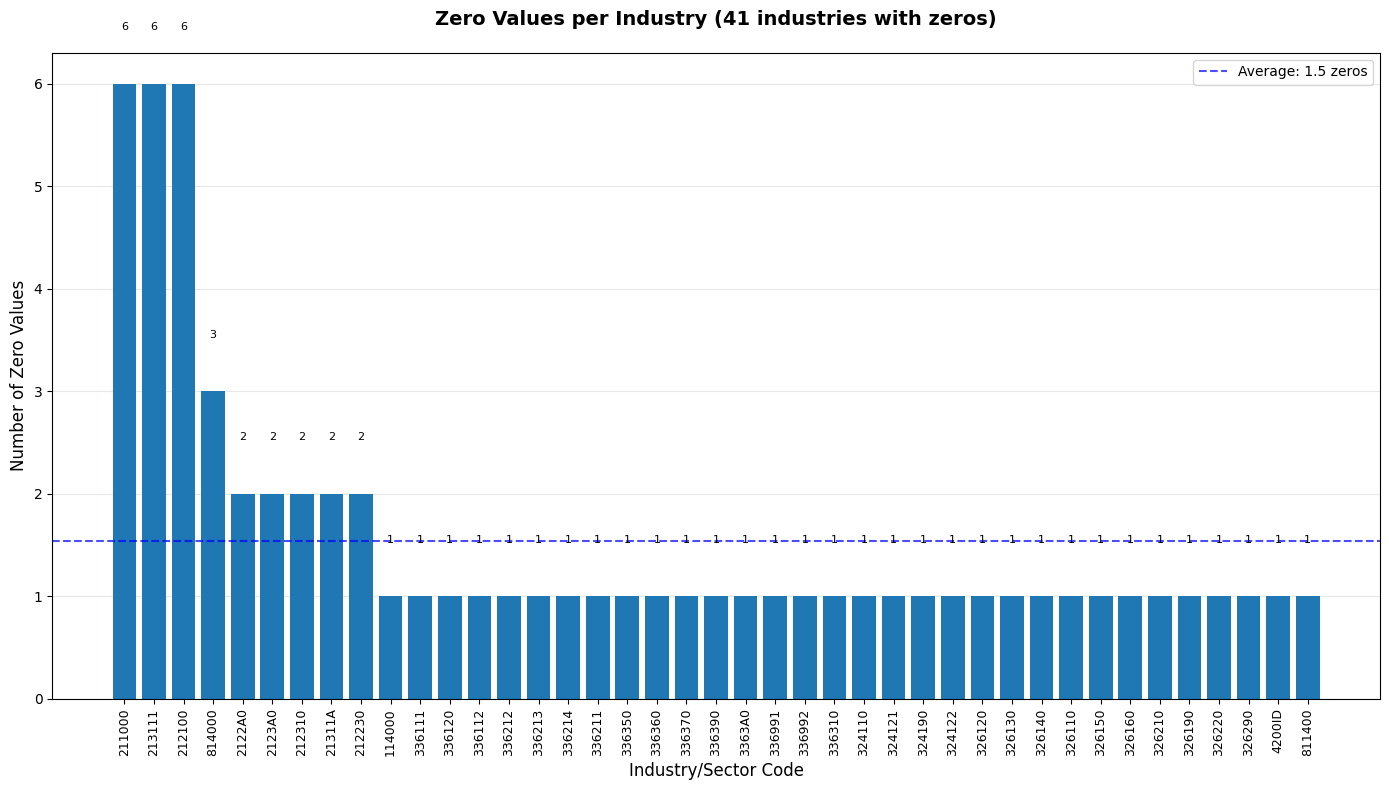


Found 41 industries with zero values
Total zero values across all industries: 63

Top 10 industries with most zeros:
   Industry  Zero_Count
1    211000           6
7    213111           6
2    212100           6
40   814000           3
4    2122A0           2
6    2123A0           2
5    212310           2
8    21311A           2
3    212230           2
0    114000           1


In [5]:
country_zeros = plot_zeros_per_country(ceda_data)

if country_zeros is not None:
    print(f"\nFound {len(country_zeros)} countries with zero values")
    print(f"Total zero values across all countries: {country_zeros['Zero_Count'].sum()}")
    print(f"\nTop 10 countries with most zeros:")
    print(country_zeros.head(10))

# Plot zeros per industry
industry_zeros = plot_zeros_per_industry(ceda_data)

if industry_zeros is not None:
    print(f"\nFound {len(industry_zeros)} industries with zero values")
    print(f"Total zero values across all industries: {industry_zeros['Zero_Count'].sum()}")
    print(f"\nTop 10 industries with most zeros:")
    print(industry_zeros.head(10))

In [6]:
summary_df, details_dict = list_missing_industries_by_country(ceda_data)

if summary_df is not None:
    # Print report
    print_missing_industries_report(summary_df, details_dict, show_details=True)
    
    # Export to CSV
    export_missing_industries_to_csv(summary_df, details_dict)
    
    # Get only top 10 countries with most missing industries
    top_summary, top_details = list_missing_industries_by_country(ceda_data, top_n=10)
    print("\n" + "="*80)
    print("TOP 10 COUNTRIES WITH MOST MISSING INDUSTRIES:")
    print_missing_industries_report(top_summary, top_details, show_details=True, max_industries_per_country=5)
    
    # You can also use the summary DataFrame for further analysis
    print("\n📈 Quick analysis of missing data distribution:")
    print(f"   • Countries with >50% missing: {len(summary_df[summary_df['Missing_Percentage'] > 50])}")
    print(f"   • Countries with >25% missing: {len(summary_df[summary_df['Missing_Percentage'] > 25])}")
    print(f"   • Countries with >10% missing: {len(summary_df[summary_df['Missing_Percentage'] > 10])}")

MISSING INDUSTRIES BY COUNTRY REPORT

📊 SUMMARY STATISTICS:
   • Countries with missing data: 12
   • Total missing industry entries: 63
   • Average missing per country: 5.2
   • Maximum missing in a country: 17
   • Average missing percentage: 1.3%

Country                   Missing Count   Missing %    Severity
--------------------------------------------------------------------------------
nan                       17.0            4.2%       Low
nan                       15.0            3.7%       Low
nan                       8.0             2.0%       Low
nan                       8.0             2.0%       Low
nan                       3.0             0.7%       Low
nan                       3.0             0.7%       Low
nan                       3.0             0.7%       Low
nan                       2.0             0.5%       Low
nan                       1.0             0.2%       Low
nan                       1.0             0.2%       Low
nan                       1.0    

In [7]:
# Use each function separately as needed

# 1. Only convert 0s to NaN (if you just want to clean the database)
cleaned_df, stats = convert_zeros_to_true_nulls(ceda_data)
output_filename = f'ceda_cleaned.csv'
cleaned_df.to_csv(output_filename, index=False)

# 2. Only create engineered nulls (if data is already cleaned)
#    You can use this on any DataFrame, not just CEDA data
benchmark_df, mask_info = create_engineered_nulls(
    cleaned_df,
    null_percentage=0.15,  # 15% engineered nulls
    random_seed=123,
    exclude_columns=['Country', 'Region']  # List non-numeric columns to exclude
)
output_filename = f'ceda_masked_{mask_info["null_percentage"]*100:.0f}pct_seed{mask_info["random_seed"]}.csv'
benchmark_df.to_csv(output_filename, index=False)
print(f"Saved to: {output_filename}")

# 3. Get the masked values for evaluation reference
masked_values = get_masked_values_df(mask_info, cleaned_df)

Converting 0s to NaN (true database nulls)...
  Converted 63 zeros to NaN
  Original zeros: 0.11% of cells
  New nulls: 0.11% of cells
Creating engineered nulls (15.0% of non-null values)...
  Total known values: 59,537
  Added 8,930 engineered nulls
  Original nulls: 63
  Total nulls after masking: 8,993
  Percentage of engineered nulls: 99.3%
Saved to: ceda_masked_15pct_seed123.csv


In [8]:
if not masked_values.empty:
    masked_values.to_csv('masked_values_reference.csv', index=False)
    print("Saved masked values reference to: masked_values_reference.csv")
    
    # Show sample of masked values
    print("\nSample of masked values (first 5):")
    print(masked_values.head())

# Summary statistics
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Original data shape: {ceda_data.shape}")
print(f"True nulls (from database 0s): {stats['total_nulls_after']:,} cells")
print(f"Engineered nulls (for testing): {mask_info['engineered_nulls_count']:,} cells")
print(f"Total cells: {stats['total_cells']:,}")
print("\nMissing data percentages:")
print(f"  True database missing: {(stats['total_nulls_after']/stats['total_cells'])*100:.2f}%")
print(f"  After adding engineered: {(mask_info['total_nulls']/stats['total_cells'])*100:.2f}%")

Saved masked values reference to: masked_values_reference.csv

Sample of masked values (first 5):
   Country  Sector  Original_Value  Row_Index Column_Name
0      NaN  322230        0.325224          8      322230
1      NaN  622000        0.115782         43      622000
2      NaN  33441A        1.013089         14      33441A
3      NaN  331410        0.939727        126      331410
4      NaN  532400        0.125859         66      532400

FINAL SUMMARY
Original data shape: (149, 402)
True nulls (from database 0s): 63 cells
Engineered nulls (for testing): 8,930 cells
Total cells: 59,749

Missing data percentages:
  True database missing: 0.11%
  After adding engineered: 15.05%


In [9]:
print("First 10 countries in original data:")
print(ceda_data['Country'].head(10).tolist())

print("\nFirst 10 countries in benchmark data:")
print(benchmark_df['Country'].head(10).tolist())


First 10 countries in original data:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

First 10 countries in benchmark data:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [10]:
# Load datasets
indicators_df = pd.read_csv('country_indicator_latest_values.csv')
emissions_df = pd.read_csv('ceda_cleaned.csv')

print(f"Indicators dataset shape: {indicators_df.shape}")
print(f"Emissions dataset shape: {emissions_df.shape}")
print()

print("=== COLUMNS IN INDICATORS DATASET ===")
print(indicators_df.columns.tolist())
print()

print("=== COLUMNS IN EMISSIONS DATASET ===")
print(emissions_df.columns.tolist())
print()

# Look for country-related columns
print("=== SEARCHING FOR COUNTRY COLUMNS ===")
print("Indicators - columns containing 'country' or 'code':")
for col in indicators_df.columns:
    if any(term in col.lower() for term in ['country', 'code', 'iso', 'name', 'id']):
        print(f"  '{col}': First value = {indicators_df[col].iloc[0] if len(indicators_df) > 0 else 'N/A'}")
print()

print("Emissions - columns containing 'country' or 'code':")
for col in emissions_df.columns:
    if any(term in col.lower() for term in ['country', 'code', 'iso', 'name', 'id']):
        print(f"  '{col}': First value = {emissions_df[col].iloc[0] if len(emissions_df) > 0 else 'N/A'}")

Indicators dataset shape: (217, 11)
Emissions dataset shape: (149, 402)

=== COLUMNS IN INDICATORS DATASET ===
['Country Name', 'Country Code', 'Fossil fuel energy consumption (% of total)', 'Energy use (kg of oil equivalent per capita)', 'GDP per capita, PPP (constant 2021 international $)', 'Manufacturing, value added (% of GDP)', 'Exports of goods and services (% of GDP)', 'Access to electricity (% of population)', 'Rail lines (total route-km)', 'Population, total', 'Urban population (% of total population)']

=== COLUMNS IN EMISSIONS DATASET ===
['Country', 'Country Code', '1111A0', '1111B0', '111200', '111300', '111400', '111900', '112120', '1121A0', '112300', '112A00', '113000', '114000', '115000', '211000', '212100', '212230', '2122A0', '212310', '2123A0', '213111', '21311A', '221100', '221200', '221300', '233210', '233262', '230301', '230302', '2332A0', '233412', '2334A0', '233230', '2332D0', '233240', '233411', '2332C0', '321100', '321200', '321910', '3219A0', '327100', '32720

In [11]:
# Load datasets
indicators_df = pd.read_csv('country_indicator_latest_values.csv')
emissions_df = pd.read_csv('ceda_cleaned.csv')

print(f"Indicators dataset shape: {indicators_df.shape}")
print(f"Emissions (CEDA) dataset shape: {emissions_df.shape}")
print()

# Step 1: Match countries
print("Matching countries between datasets...")
matched_indicators, matched_emissions, match_stats = match_countries(
    indicators_df, 
    emissions_df,
    indicators_country_col='Country Code',    # Your actual column name
    emissions_country_col='Country Code',     # Your actual column name
    indicators_name_col='Country Name',       # Your actual column name
    emissions_name_col='Country'              # Your actual column name
)

# Print report focused on CEDA dataset
print_matching_report(match_stats, focus_on_ceda=True)
print()

# Save missing countries with both names and codes
filename, indicators_only_df, emissions_only_df = save_missing_countries(
    indicators_df, 
    emissions_df,
    indicators_country_col='Country Code',
    emissions_country_col='Country Code',
    indicators_name_col='Country Name',
    emissions_name_col='Country',
    filename="missing_countries_comprehensive.xlsx"
)

# Show preview of missing countries
print("\n📋 PREVIEW OF MISSING COUNTRIES:")
if len(emissions_only_df) > 0:
    print(f"\nTop 10 CEDA countries missing from indicators:")
    print(emissions_only_df.head(10).to_string(index=False))
    
if len(indicators_only_df) > 0:
    print(f"\nTop 10 indicator countries missing from CEDA:")
    print(indicators_only_df.head(10).to_string(index=False))

# Display matched countries count
print(f"\n✅ Matched countries available for correlation analysis: {match_stats['n_matched']}")
print(f"   • These countries will be used for correlation calculations")
print(f"   • Representing {match_stats['match_percentage_in_emissions']:.1f}% of CEDA dataset")

if match_stats['n_matched'] == 0:
    print("\n❌ No countries matched! Cannot calculate correlations.")
else:
    print(f"\n✅ Proceeding with {match_stats['n_matched']} matched countries for correlation analysis...")
    # Continue with correlation calculations

Indicators dataset shape: (217, 11)
Emissions (CEDA) dataset shape: (149, 402)

Matching countries between datasets...
COUNTRY MATCHING REPORT

📊 FOCUS ON CEDA DATASET:
   • Countries in CEDA dataset: 149
   • CEDA countries matched with indicators: 147
   • CEDA coverage by indicators: 98.7%
   • CEDA countries NOT in indicators: 2

📍 CEDA Countries missing from indicators:
    1. ROW - nan
    2. TWN - nan

📈 MATCHING EFFICIENCY:
   • CEDA dataset coverage: 98.7%
   ✅ Good: High coverage of CEDA dataset (≥80%)

🔍 ANALYSIS:
   • Indicators dataset has more unique countries (+68)


✓ Country comparison exported to: missing_countries_comprehensive.xlsx
   • Summary sheet: Overall statistics
   • Only_In_Indicators: 70 countries only in indicators
   • Only_In_Emissions: 2 countries only in emissions

📋 PREVIEW OF MISSING COUNTRIES:

Top 10 CEDA countries missing from indicators:
Country_Code Country_Name
         ROW          nan
         TWN          nan

Top 10 indicator countries mis

In [ ]:
# Step 2: Calculate correlations
print("Calculating correlations between indicators and industry emissions...")
correlation_df = calculate_correlations_optimized(
    matched_indicators, 
    matched_emissions,
    indicators_country_col='Country Code',    # Your actual column name
    emissions_country_col='Country Code',     # Your actual column name
    indicators_name_col='Country Name',       # Your actual column name
    emissions_name_col='Country'              # Your actual column name
)

Calculating correlations between indicators and industry emissions...
Calculating correlations for 10 indicators × 401 industries...
  Processing indicator 1/10...


ValueError: could not convert string to float: 'Afghanistan'

In [ ]:
# Step 3: Rank indicators by average correlation across industries
print("TOP 20 INDICATORS BY AVERAGE ABSOLUTE CORRELATION:")
print("=" * 80)
indicator_rankings = rank_indicators_by_correlation(correlation_df, top_n=20)

for idx, (indicator, row) in enumerate(indicator_rankings.iterrows(), 1):
    avg_corr = row['Correlation']
    avg_abs_corr = row['Abs_Correlation']
    n_industries = row['N_Industries']
    direction = "positive" if avg_corr > 0 else "negative"
    
    print(f"{idx:2d}. {indicator:50s} | Avg correlation: {avg_corr:+.3f} ({direction})")
    print(f"    {'':50s}   Avg absolute: {avg_abs_corr:.3f} | Industries: {n_industries}")
print()

TOP 20 INDICATORS BY AVERAGE ABSOLUTE CORRELATION:
 1. Population, total                                  | Avg correlation: +0.239 (positive)
                                                         Avg absolute: 0.242 | Industries: 400.0
 2. Rail lines (total route-km)                        | Avg correlation: +0.241 (positive)
                                                         Avg absolute: 0.242 | Industries: 400.0
 3. Access to electricity (% of population)            | Avg correlation: +0.190 (positive)
                                                         Avg absolute: 0.190 | Industries: 400.0
 4. Energy use (kg of oil equivalent per capita)       | Avg correlation: +0.144 (positive)
                                                         Avg absolute: 0.144 | Industries: 400.0
 5. GDP per capita, PPP (constant 2021 international $) | Avg correlation: -0.109 (negative)
                                                         Avg absolute: 0.136 | Industries: 400.0
 6.

In [ ]:
# Step 4: Show industry-specific top correlations
print("INDUSTRY-SPECIFIC TOP CORRELATIONS:")
print("=" * 80)
industry_analysis = analyze_industry_specific_correlations(correlation_df, top_per_industry=3)

for industry, results in industry_analysis.items():
    print(f"\nIndustry: {industry}")
    print(f"Total indicators analyzed: {results['n_indicators']}")
    
    print("  Top positive correlations:")
    for _, row in results['top_positive'].iterrows():
        print(f"    - {row['Indicator']}: {row['Correlation']:.3f} (n={row['N_Countries']})")
    
    print("  Top negative correlations:")
    for _, row in results['top_negative'].iterrows():
        print(f"    - {row['Indicator']}: {row['Correlation']:.3f} (n={row['N_Countries']})")

# Optional: Save results to files
print("\nSaving results to files...")
correlation_df.to_csv('all_correlations.csv', index=False)
indicator_rankings.to_csv('indicator_rankings.csv')

# Save industry-specific results
with pd.ExcelWriter('industry_specific_correlations.xlsx') as writer:
    for industry, results in industry_analysis.items():
        # Combine positive and negative
        combined = pd.concat([
            results['top_positive'].assign(Type='Positive'),
            results['top_negative'].assign(Type='Negative')
        ])
        combined.to_excel(writer, sheet_name=industry[:31], index=False)

print("Analysis complete! Files saved:")
print("  - all_correlations.csv: All individual correlations")
print("  - indicator_rankings.csv: Top indicators by average correlation")
print("  - industry_specific_correlations.xlsx: Top correlations per industry")

INDUSTRY-SPECIFIC TOP CORRELATIONS:

Industry: 1111A0
Total indicators analyzed: 8
  Top positive correlations:
    - Access to electricity (% of population): 0.234 (n=130)
    - Energy use (kg of oil equivalent per capita): 0.230 (n=105)
    - Rail lines (total route-km): 0.126 (n=47)
  Top negative correlations:
    - Manufacturing, value added (% of GDP): -0.139 (n=128)
    - Population, total: -0.051 (n=130)
    - GDP per capita, PPP (constant 2021 international $): -0.050 (n=130)

Industry: 1111B0
Total indicators analyzed: 8
  Top positive correlations:
    - Energy use (kg of oil equivalent per capita): 0.216 (n=105)
    - Access to electricity (% of population): 0.188 (n=130)
    - Rail lines (total route-km): 0.106 (n=47)
  Top negative correlations:
    - Manufacturing, value added (% of GDP): -0.179 (n=128)
    - GDP per capita, PPP (constant 2021 international $): -0.086 (n=130)
    - Population, total: -0.078 (n=130)

Industry: 111200
Total indicators analyzed: 8
  Top pos